# Phase 1: Bias-Aware Backtesting Strategy

This notebook is the reviewable, offline-runnable companion to the reusable code in `src/phase1_backtest/`. It evaluates three long/cash trading rules and a buy-and-hold benchmark across nine ETFs/stocks over one fixed 2014–2024 window.

**Repository:** <https://github.com/zy066299-gif/Kevin>

[Open this notebook in Google Colab](https://colab.research.google.com/github/zy066299-gif/Kevin/blob/main/notebooks/phase1_backtesting.ipynb).

The cleaned snapshot is included, so a routine notebook run does not need a live Yahoo Finance request.

> Educational analysis only. These in-sample results omit most live-trading frictions and are not investment advice.

## Google Colab setup

Run this cell first in Colab. It clones the shared repository and installs the pinned project dependencies. When the notebook is running locally, the cell safely leaves the current environment unchanged.

In [1]:
from pathlib import Path
import sys

REPOSITORY_URL = "https://github.com/zy066299-gif/Kevin.git"
COLAB_PROJECT = Path("/content/Kevin")

if "google.colab" in sys.modules:
    if not COLAB_PROJECT.exists():
        !git clone {REPOSITORY_URL} {COLAB_PROJECT}
    %cd /content/Kevin
    !python -m pip install -q -r requirements-colab.txt
    !python -m pip install -q -e . --no-deps
else:
    print(f"Local run detected; project remains at {Path.cwd().resolve()}")

Local run detected; project remains at /Users/yb/Documents/Codex/2026-09-21/phase-1-backtesting-strategy-1-x20/outputs/phase1_backtesting/notebooks


## TL;DR

The next cell computes this summary directly from the saved, reproducible result tables. It is deliberately generated from the outputs rather than typed by hand.

In [2]:
from pathlib import Path
import base64
import html
import sys

import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(path.resolve() for path in candidates if (path / "config" / "phase1.json").exists())
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from phase1_backtest import run_pipeline

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.options.display.float_format = "{:,.4f}".format

result = run_pipeline(PROJECT_ROOT, refresh_data=False)
metrics = result["metrics"].copy()
summary = result["summary"].copy()
quality = result["quality"].copy()
details = result["details"].copy()
cost_comparison = result["cost_comparison"].copy()

def embedded_png(path, width, alt):
    encoded = base64.b64encode(Path(path).read_bytes()).decode("ascii")
    safe_alt = html.escape(alt, quote=True)
    return HTML(
        f'<img src="data:image/png;base64,{encoded}" width="{width}" '
        f'alt="{safe_alt}" style="max-width:100%;height:auto;">'
    )

best = metrics.sort_values("annualized_return", ascending=False).iloc[0]
best_median = summary.sort_values("median_annualized_return", ascending=False).iloc[0]
review_count = int((quality["status"] != "PASS").sum())
timing_beats = int(
    summary.loc[summary["strategy"].ne("Buy & Hold"), "tickers_beating_buy_hold"].sum()
)
beat_sentence = (
    "No timing rule beat buy-and-hold on annualized return for any of the nine fixed instruments in this sample."
    if timing_beats == 0
    else f"The timing rules beat buy-and-hold in {timing_beats} strategy/ticker comparisons."
)
display(Markdown(
    f"""
- **Best individual result:** {best['strategy']} on {best['ticker']} at **{best['annualized_return']:.1%} annualized**.
- **Best strategy median:** {best_median['strategy']} at **{best_median['median_annualized_return']:.1%} annualized** across nine instruments.
- **Benchmark comparison:** {beat_sentence}
- **Data quality:** **{review_count}** ticker profiles require review; the snapshot contains **{len(result['cleaned']):,}** valid ticker-date rows.
"""
))


- **Best individual result:** Buy & Hold on AAPL at **27.6% annualized**.
- **Best strategy median:** Buy & Hold at **14.2% annualized** across nine instruments.
- **Benchmark comparison:** No timing rule beat buy-and-hold on annualized return for any of the nine fixed instruments in this sample.
- **Data quality:** **0** ticker profiles require review; the snapshot contains **27,180** valid ticker-date rows.


## Context & Methods

### Key assumptions

- Universe: SPY, QQQ, IWM, AAPL, JPM, JNJ, XOM, WMT, and CAT.
- Indicator warm-up begins 2013-01-02; performance is reported from 2014-01-02 through 2024-12-31.
- Returns and all indicators use **adjusted close**, so stock splits and distributions do not create artificial signals.
- Signals are observed at close `t`; `position[t] = signal[t-1]`. This enforces a one-session lag.
- Positions are long (`1`) or cash (`0`), fractional shares are allowed, and cash earns 0%.
- Headline results use zero transaction costs. A separate sensitivity charges 10 bp on each entry or exit.
- Sharpe uses a 0% annual risk-free rate and 252 trading sessions per year.

### Rules

1. **Buy & Hold:** invested after the first evaluation close.
2. **SMA 50/200:** long when the 50-session adjusted-close SMA is above the 200-session SMA.
3. **Momentum 12M (absolute):** long when the 252-session adjusted return is positive. This is time-series momentum, chosen because the brief requests a separate result for every ticker; it is not a cross-sectional top-N portfolio.
4. **RSI 14:** Wilder RSI; enter below 30 and remain long until RSI reaches 50.

The first row of each equity curve is normalized to $1. Metrics begin with the following session return, which makes buy-and-hold reconcile to last adjusted close divided by first evaluation adjusted close.

### Lag check: inspect a real signal transition

In [3]:
spy_sma = (
    details.loc[(details["ticker"] == "SPY") & (details["strategy"] == "SMA 50/200")]
    .sort_values("date")
    .reset_index(drop=True)
)
transition_locations = np.flatnonzero(spy_sma["position"].diff().abs().fillna(0).to_numpy() > 0)
anchor = int(transition_locations[0])
lag_example = spy_sma.loc[
    max(0, anchor - 2): anchor + 2,
    ["date", "signal", "position", "asset_return", "strategy_return", "equity"],
].copy()
lag_example["position_x_asset_return"] = lag_example["position"] * lag_example["asset_return"]
lag_example = lag_example.rename(columns={
    "date": "Date",
    "signal": "Close signal",
    "position": "Lagged position",
    "asset_return": "Asset return",
    "strategy_return": "Strategy return",
    "equity": "Equity",
    "position_x_asset_return": "Position × return",
})
display(lag_example.style.hide(axis="index").format({
    "Close signal": "{:.0f}",
    "Lagged position": "{:.0f}",
    "Asset return": "{:.2%}",
    "Strategy return": "{:.2%}",
    "Position × return": "{:.2%}",
    "Equity": "{:.3f}",
}))

Date,Close signal,Lagged position,Asset return,Strategy return,Equity,Position × return
2015-09-02 00:00:00,1,1,1.90%,1.90%,1.099,1.90%
2015-09-03 00:00:00,0,1,0.07%,0.07%,1.100,0.07%
2015-09-04 00:00:00,0,0,-1.51%,-0.00%,1.100,-0.00%
2015-09-08 00:00:00,0,0,2.51%,0.00%,1.100,0.00%
2015-09-09 00:00:00,0,0,-1.34%,-0.00%,1.100,-0.00%


The close signal and realized position can differ on a transition row because the position is the prior session's signal. The last two columns reconcile exactly in the zero-cost headline backtest.

## Data

### 1. Inspect coverage and corporate actions

In [4]:
coverage_columns = [
    "ticker", "rows_clean", "first_date", "last_date",
    "missing_dates_vs_universe_calendar", "dividend_events", "split_events", "status"
]
quality_view = quality[coverage_columns].rename(columns={
    "ticker": "Ticker",
    "rows_clean": "Clean rows",
    "first_date": "First date",
    "last_date": "Last date",
    "missing_dates_vs_universe_calendar": "Missing vs universe calendar",
    "dividend_events": "Dividend events",
    "split_events": "Split events",
    "status": "Status",
})
display(quality_view.style.hide(axis="index"))

split_rows = result["cleaned"].loc[
    result["cleaned"]["stock_splits"].ne(0), ["date", "ticker", "stock_splits"]
]
display(Markdown("**Recorded split events**"))
display(
    split_rows.rename(columns={"date": "Date", "ticker": "Ticker", "stock_splits": "Split factor"})
    .reset_index(drop=True)
    .style.hide(axis="index")
)

Ticker,Clean rows,First date,Last date,Missing vs universe calendar,Dividend events,Split events,Status
SPY,3020,2013-01-02,2024-12-31,0,48,0,PASS
QQQ,3020,2013-01-02,2024-12-31,0,49,0,PASS
IWM,3020,2013-01-02,2024-12-31,0,48,0,PASS
AAPL,3020,2013-01-02,2024-12-31,0,48,2,PASS
JPM,3020,2013-01-02,2024-12-31,0,48,0,PASS
JNJ,3020,2013-01-02,2024-12-31,0,48,0,PASS
XOM,3020,2013-01-02,2024-12-31,0,48,0,PASS
WMT,3020,2013-01-02,2024-12-31,0,48,1,PASS
CAT,3020,2013-01-02,2024-12-31,0,47,0,PASS


**Recorded split events**

Date,Ticker,Split factor
2014-06-09 00:00:00,AAPL,7.000000
2020-08-31 00:00:00,AAPL,4.000000
2024-02-26 00:00:00,WMT,3.000000


All nine tickers have identical observed US trading dates in this download. The cleaner checks ticker/date uniqueness, positive adjusted prices, OHLC consistency, nonnegative volume, and missing dates against the union of the selected US instruments. It does **not** forward-fill missing prices.

## Results

### 2. Compare all required metrics

In [5]:
display_columns = [
    "ticker", "strategy", "total_return", "annualized_return", "annualized_volatility",
    "sharpe_ratio", "max_drawdown", "win_rate", "exposure", "entries"
]
formatted = metrics[display_columns].copy()
formatted = formatted.rename(columns={
    "ticker": "Ticker",
    "strategy": "Strategy",
    "total_return": "Total return",
    "annualized_return": "Annualized return",
    "annualized_volatility": "Annualized volatility",
    "sharpe_ratio": "Sharpe ratio",
    "max_drawdown": "Maximum drawdown",
    "win_rate": "Active-day win rate",
    "exposure": "Exposure",
    "entries": "Entries",
})
percent_columns = [
    "Total return", "Annualized return", "Annualized volatility", "Maximum drawdown", "Active-day win rate", "Exposure"
]
formatters = {column: "{:.1%}" for column in percent_columns}
formatters["Sharpe ratio"] = "{:.2f}"
display(formatted.style.hide(axis="index").format(formatters))

Ticker,Strategy,Total return,Annualized return,Annualized volatility,Sharpe ratio,Maximum drawdown,Active-day win rate,Exposure,Entries
AAPL,Buy & Hold,1353.0%,27.6%,27.9%,1.01,38.5%,53.3%,100.0%,1
AAPL,SMA 50/200,652.0%,20.2%,24.4%,0.88,45.6%,53.2%,78.4%,6
AAPL,Momentum 12M (absolute),517.3%,18.0%,25.5%,0.78,36.4%,52.8%,85.1%,32
AAPL,RSI 14,37.6%,2.9%,14.0%,0.28,25.9%,53.1%,9.3%,15
CAT,Buy & Hold,441.1%,16.6%,29.0%,0.68,44.6%,51.9%,100.0%,1
CAT,SMA 50/200,105.4%,6.8%,21.5%,0.41,59.5%,52.2%,65.3%,9
CAT,Momentum 12M (absolute),173.6%,9.6%,21.4%,0.54,42.7%,52.0%,67.7%,24
CAT,RSI 14,75.7%,5.3%,13.6%,0.45,28.0%,52.8%,13.0%,21
IWM,Buy & Hold,124.0%,7.6%,22.0%,0.44,41.1%,53.1%,100.0%,1
IWM,SMA 50/200,4.1%,0.4%,16.7%,0.11,50.3%,52.7%,70.7%,9


### 3. Scan annualized returns across the full matrix


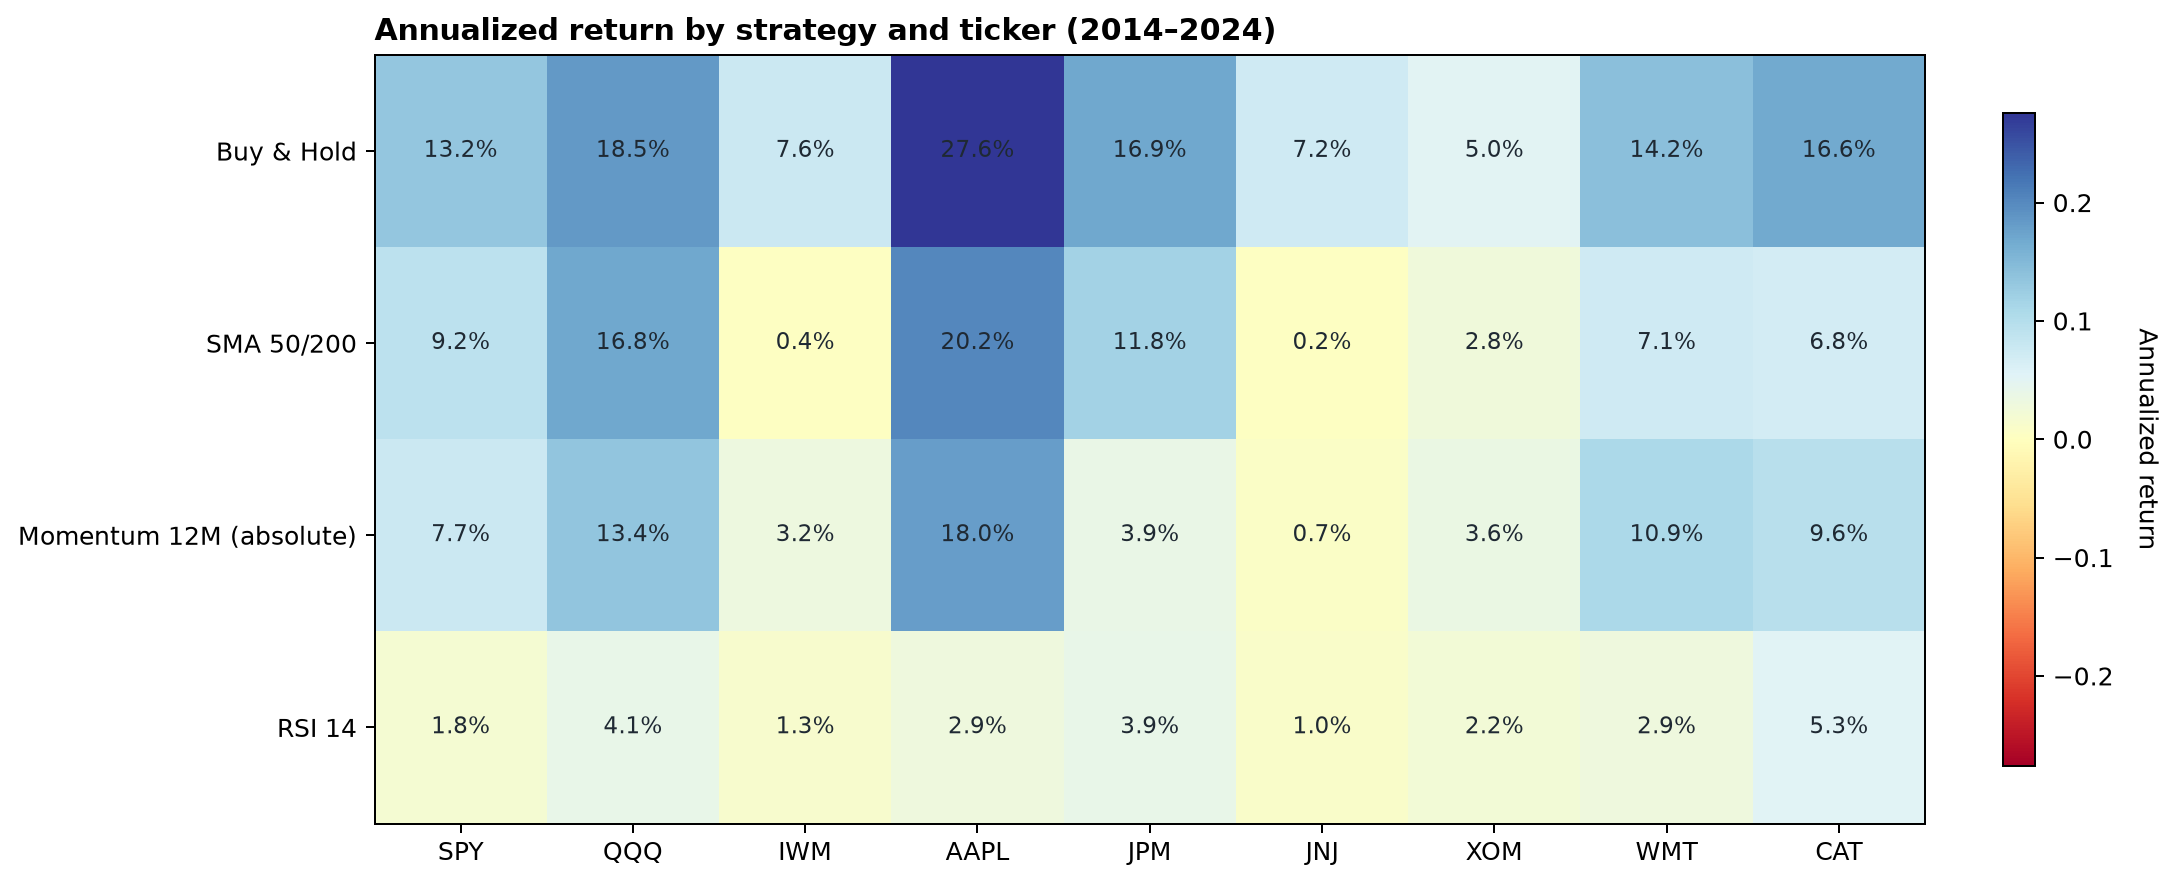

In [6]:
display(embedded_png(
    PROJECT_ROOT / "figures" / "annualized_return_heatmap.png",
    width=1050,
    alt="Heatmap of annualized return for four strategies across nine tickers",
))

### 4. Compare cross-universe medians


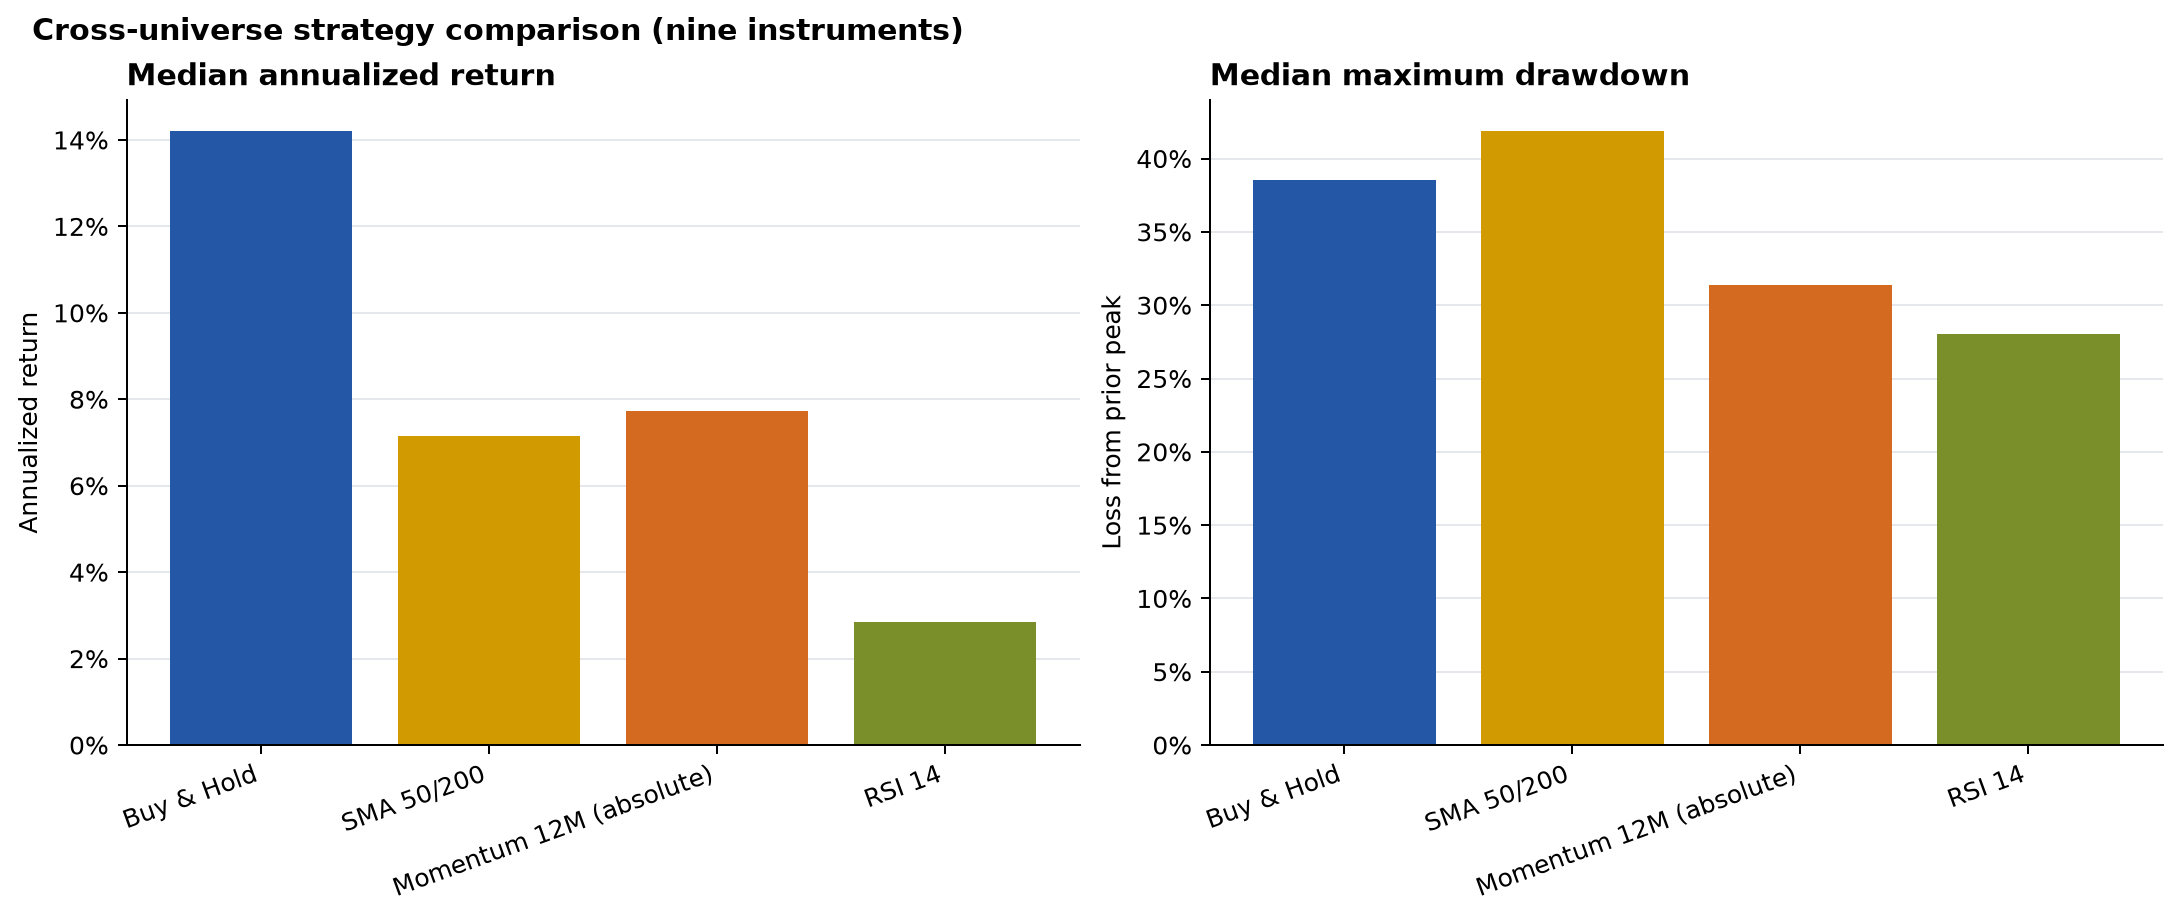

Strategy,Median annualized return,Median Sharpe ratio,Median maximum drawdown,Median active-day win rate,Median exposure,Tickers beating buy-and-hold
Buy & Hold,14.2%,0.72,38.5%,53.1%,100.0%,Benchmark
SMA 50/200,7.1%,0.48,41.9%,52.9%,74.6%,0/9
Momentum 12M (absolute),7.7%,0.54,31.4%,52.7%,76.6%,0/9
RSI 14,2.9%,0.28,28.0%,53.1%,9.3%,0/9


In [7]:
display(embedded_png(
    PROJECT_ROOT / "figures" / "median_performance.png",
    width=1050,
    alt="Bar charts of median annualized return and maximum drawdown by strategy",
))
summary_view = summary[[
    "strategy", "median_annualized_return", "median_sharpe_ratio", "median_max_drawdown",
    "median_win_rate", "median_exposure", "tickers_beating_buy_hold", "ticker_count"
]].copy()
summary_view["beat_buy_hold"] = np.where(
    summary_view["strategy"].eq("Buy & Hold"),
    "Benchmark",
    summary_view["tickers_beating_buy_hold"].astype(str) + "/" + summary_view["ticker_count"].astype(str),
)
summary_view = summary_view.drop(columns=["tickers_beating_buy_hold", "ticker_count"]).rename(columns={
    "strategy": "Strategy",
    "median_annualized_return": "Median annualized return",
    "median_sharpe_ratio": "Median Sharpe ratio",
    "median_max_drawdown": "Median maximum drawdown",
    "median_win_rate": "Median active-day win rate",
    "median_exposure": "Median exposure",
    "beat_buy_hold": "Tickers beating buy-and-hold",
})
display(summary_view.style.hide(axis="index").format({
    "Median annualized return": "{:.1%}",
    "Median Sharpe ratio": "{:.2f}",
    "Median maximum drawdown": "{:.1%}",
    "Median active-day win rate": "{:.1%}",
    "Median exposure": "{:.1%}",
}))

### 5. Inspect one complete equity-curve example


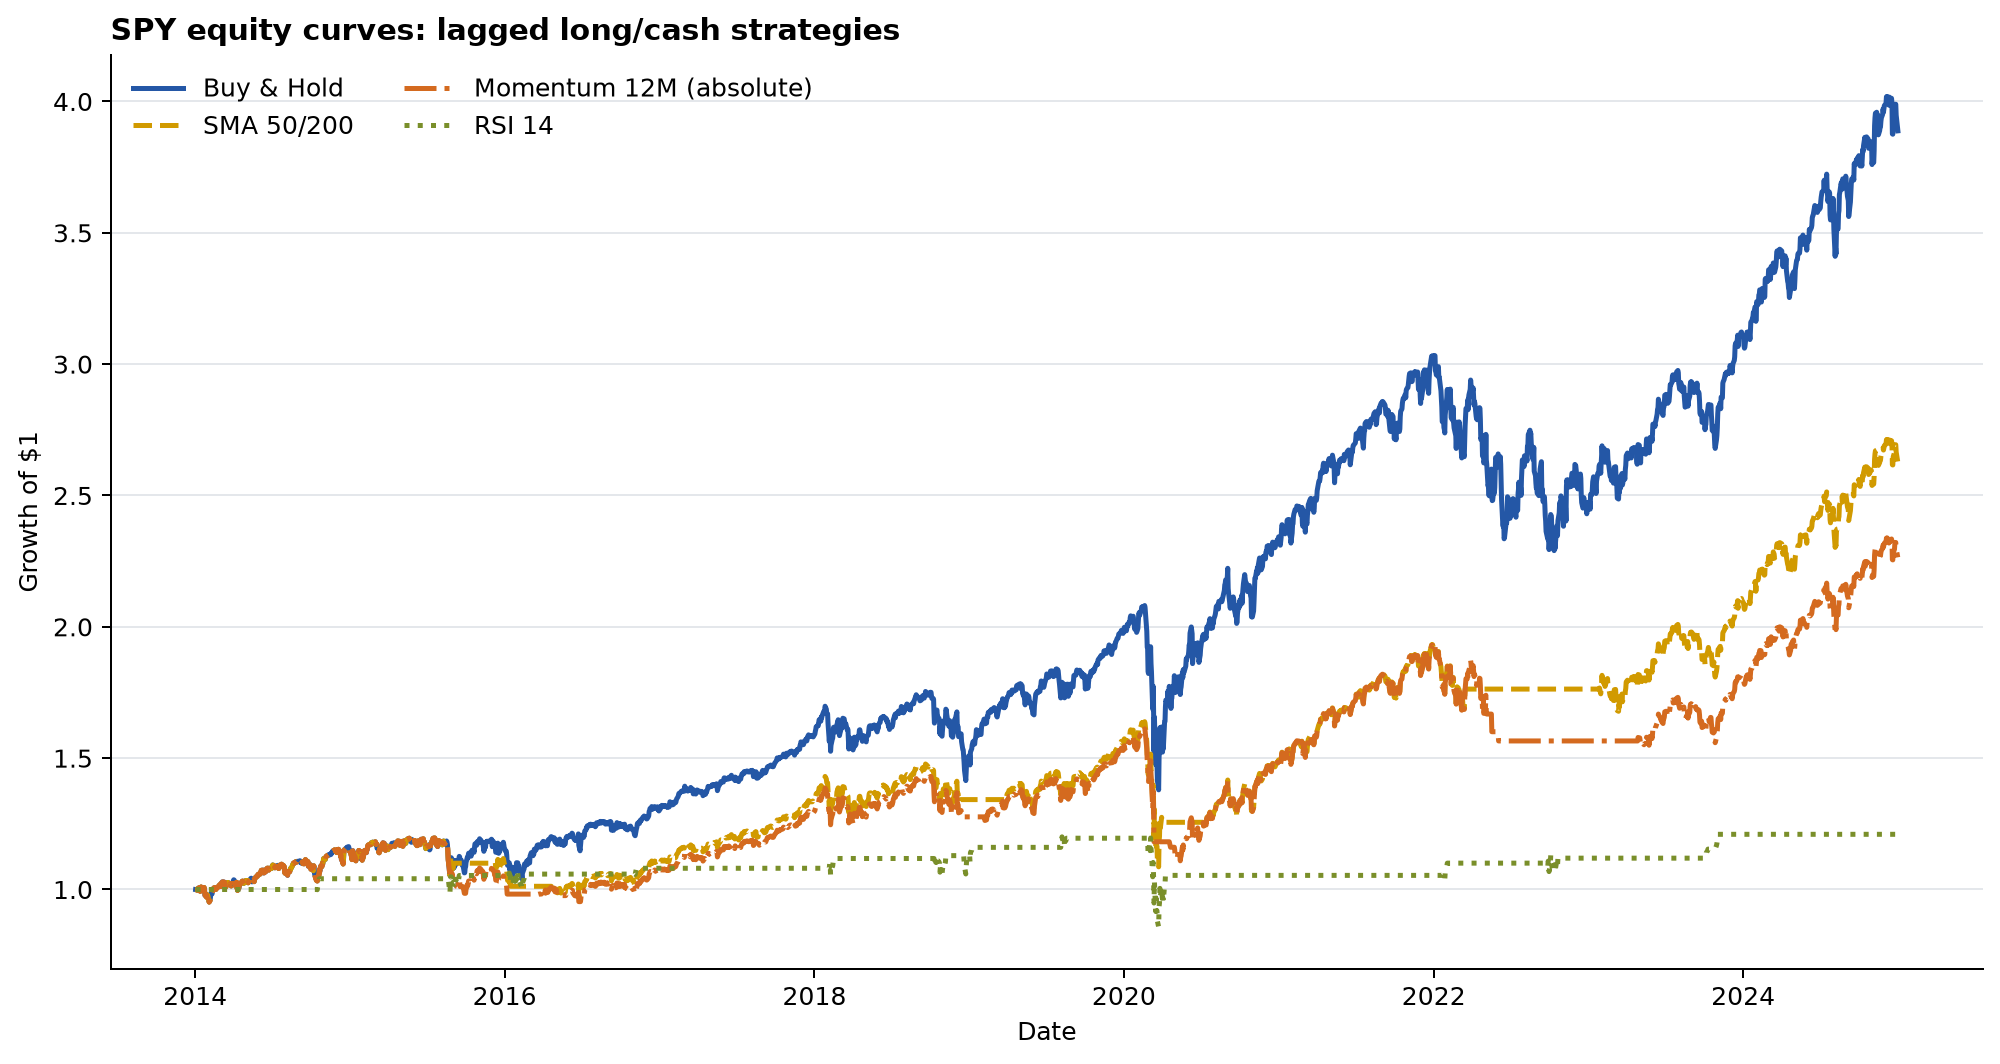

In [8]:
display(embedded_png(
    PROJECT_ROOT / "figures" / "spy_equity_curves.png",
    width=1000,
    alt="SPY equity curves for buy-and-hold, SMA, momentum, and RSI strategies",
))

SPY shows the central trade-off in this particular sample: the timing rules spent meaningful time in cash and sometimes reduced drawdowns, but they also missed parts of a strong long-run equity advance. The exact result differs by ticker, so the full table—not one chart—should govern conclusions.

### 6. Stress the zero-cost assumption

In [9]:
cost_summary = (
    cost_comparison.groupby("strategy", sort=False)
    .agg(
        median_ann_return_base=("annualized_return_base", "median"),
        median_ann_return_with_cost=("annualized_return_with_cost", "median"),
        median_ann_return_drag=("annualized_return_drag", "median"),
    )
    .reset_index()
)
cost_bps = result["config"].cost_sensitivity_bps
cost_summary = cost_summary.rename(columns={
    "strategy": "Strategy",
    "median_ann_return_base": "Median annualized return (0 bp)",
    "median_ann_return_with_cost": f"Median annualized return ({cost_bps:g} bp)",
    "median_ann_return_drag": "Median annualized drag",
})
display(cost_summary.style.hide(axis="index").format({
    "Median annualized return (0 bp)": "{:.2%}",
    f"Median annualized return ({cost_bps:g} bp)": "{:.2%}",
    "Median annualized drag": "{:.2%}",
}))

Strategy,Median annualized return (0 bp),Median annualized return (10 bp),Median annualized drag
Buy & Hold,14.21%,14.20%,0.01%
SMA 50/200,7.14%,6.93%,0.15%
Momentum 12M (absolute),7.72%,7.20%,0.55%
RSI 14,2.85%,2.57%,0.30%


## Takeaways

1. **Buy-and-hold led this fixed sample.** Its median CAGR was 14.2%, versus 7.7% for momentum, 7.1% for SMA, and 2.9% for RSI.
2. **Timing changed risk and exposure, not just return.** Momentum's median maximum drawdown was lower than buy-and-hold's, while RSI spent roughly nine-tenths of sessions in cash.
3. **No timing rule beat buy-and-hold on CAGR for any of the nine assets.** That is an observed result for this window, not a universal claim about the strategies.
4. **The low-exposure RSI result needs exposure beside win rate.** Its active-day win rate looks similar to other rules, but it participated in far fewer sessions.
5. **Trading costs matter most for rules with more turnover.** The 10 bp table makes that omitted friction visible.

### Important limitations

- The universe is selected today and contains only long-lived survivors.
- Results are in-sample and include many comparisons, so the best cell may be lucky.
- Yahoo data can be revised; the snapshot hash and retrieval metadata are saved for reproducibility.
- Close-to-close modeling does not capture next-open gaps, realistic order fills, taxes, shorting constraints, or market impact.
- Cash earns 0%, which understates long/cash rules during high-rate periods.
- A stronger Phase 2 would add point-in-time constituents, delisted securities, walk-forward validation, risk-free cash returns, parameter robustness, and transaction-cost modeling.

## Checks

The automated suite covers signal lagging, future-data invariance, Wilder RSI edge cases, benchmark reconciliation, a hand-checked 25% drawdown, zero-volatility Sharpe handling, data cleaning, and transaction costs. The run manifest also confirms binary positions, finite reported metrics, and identical evaluation coverage across strategies within each ticker.

In [10]:
result["manifest"]["validation"]

{'same_evaluation_dates_per_ticker': True,
 'finite_reported_metrics': True,
 'positions_binary': True}

## Next Steps

- Agree on whether Phase 2 should keep per-ticker time-series momentum or add a separate monthly cross-sectional portfolio.
- Add an out-of-sample or walk-forward period before tuning any thresholds.